In [38]:
import itertools
import math
import time
import csv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns
from scipy.stats import gaussian_kde


round = 'Round5'
column_names  = ['NP1', 'NP2', 'NP3', 'NP4','NP5', 'NP6', 'NP7', 'NP8','NP9', 'NP10']
hf1 = pd.read_csv(f"heatflux_all_{round}_p1.csv",header=None, names=column_names)
hf2 = pd.read_csv(f"heatflux_all_{round}_p2.csv",header=None, names=column_names)
hf3 = pd.read_csv(f"heatflux_all_{round}_p3.csv",header=None, names=column_names)
hf4 = pd.read_csv(f"heatflux_all_{round}_p4.csv",header=None, names=column_names)
hf5 = pd.read_csv(f"heatflux_all_{round}_p5.csv",header=None, names=column_names)

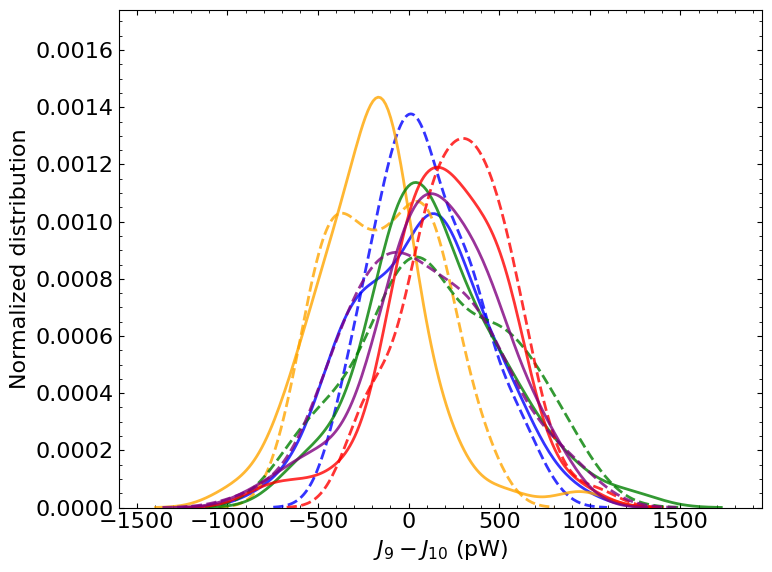

In [39]:
# Plot only panel (f): KDE distributions of signed J9 - J10
# Negative values are retained.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# -------------------------------------------------------
# Input:
# `datasets` must already be a list of five DataFrames:
# [hf1, hf2, hf3, hf4, hf5]
#
# Each DataFrame must have:
# J9  in column index 8
# J10 in column index 9
# -------------------------------------------------------

datasets = [hf1, hf2, hf3, hf4, hf5]

labels = [f"Rank {i} (Top 5)" for i in range(1, 6)]
base_colors = ['blue', 'orange', 'green', 'red', 'purple']

SMALL_SIZE = 16

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', labelsize=SMALL_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=10)


# -------------------------------------------------------
# Calculate signed J9 - J10 for each Top-5 setting
# -------------------------------------------------------

j_difference = pd.DataFrame({
    f"Rank {i + 1}": (
        dataframe.iloc[:, 8].to_numpy()
        - dataframe.iloc[:, 9].to_numpy()
    ) * 6.95
    for i, dataframe in enumerate(datasets)
})


# -------------------------------------------------------
# Panel (f): KDE plot
# Solid lines:  Label 1, first 50 rows
# Dashed lines: Label 0, rows 50 onward
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

for i, (label, base_color) in enumerate(zip(labels, base_colors)):

    values = j_difference[f"Rank {i + 1}"]

    # Label 0: rows 50 onward (dashed)
    values_label0 = values.iloc[50:].dropna()

    if len(values_label0) >= 2 and values_label0.nunique() > 1:
        sns.kdeplot(
            data=values_label0,
            ax=ax,
            color=base_color,
            linewidth=2,
            linestyle='--',
            alpha=0.8,
            fill=False,
            label=f'{label}: Label 0',
            warn_singular=False
        )

    elif len(values_label0) == 1:
        ax.axvline(
            values_label0.iloc[0],
            color=base_color,
            linestyle='--',
            linewidth=2,
            alpha=0.8,
            label=f'{label}: Label 0 (constant)'
        )

    # Label 1: first 50 rows (solid)
    values_label1 = values.iloc[:50].dropna()

    if len(values_label1) >= 2 and values_label1.nunique() > 1:
        sns.kdeplot(
            data=values_label1,
            ax=ax,
            color=base_color,
            linewidth=2,
            linestyle='-',
            alpha=0.8,
            fill=False,
            label=f'{label}: Label 1',
            warn_singular=False
        )

    elif len(values_label1) == 1:
        ax.axvline(
            values_label1.iloc[0],
            color=base_color,
            linestyle='-',
            linewidth=2,
            alpha=0.8,
            label=f'{label}: Label 1 (constant)'
        )


# Zero reference line: separates J9 > J10 from J9 < J10
#ax.axvline(
#    0,
#    color='black',
#    linestyle=':',
#    linewidth=1.2,
#    alpha=0.8
#)

ax.set_xlabel(r'$J_{9} - J_{10}$ (pW)')
ax.set_ylabel('Normalized distribution')

# Negative values are included.
ax.set_xlim((-1600, 1950))
ax.set_ylim((0, 0.00174))

ax.minorticks_on()
ax.tick_params(
    axis='both',
    bottom=True,
    top=True,
    left=True,
    right=True,
    direction='in',
    which='both',
    labelsize=16
)

#ax.legend(
#    framealpha=0.0,
#    loc='upper right',
#    fontsize=10,
#    ncol=1
#)

#ax.text(
#    -0.12, 1.06, '(f)',
#    transform=ax.transAxes,
#    fontsize=20,
#    va='top',
#    ha='left'
#)

plt.tight_layout()

plt.savefig(
    f'submit2_{round}_top5_J9_minus_J10_KDE.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()